In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from IPython.display import display
from datetime import datetime
from operator import attrgetter
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import unicodedata
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# 1. Descriptiva

In [17]:
CreditMembres = pd.read_csv('/Users/barbarajunqueira/DataAnalyst/VestuariCompartit/Tienda/01-Tratados/CreditMembres_treated.csv')
CreditMembres = CreditMembres.drop(columns='Unnamed: 0')
EvolucioMembres = pd.read_csv('/Users/barbarajunqueira/DataAnalyst/VestuariCompartit/Tienda/01-Tratados/EvolucioMembres_treated.csv')
EvolucioMembres = EvolucioMembres.drop(columns='Unnamed: 0')
EvolucioMembres['alta'] = pd.to_datetime(EvolucioMembres['alta']).dt.date
EvolucioMembres['ultim_pagament'] = pd.to_datetime(EvolucioMembres['ultim_pagament']).dt.date
VisitesiCanvis = pd.read_csv('/Users/barbarajunqueira/DataAnalyst/VestuariCompartit/Tienda/01-Tratados/VisitesiCanvis_treated.csv')
VisitesiCanvis = VisitesiCanvis.drop(columns='Unnamed: 0')
MembresActius = pd.read_csv('/Users/barbarajunqueira/DataAnalyst/VestuariCompartit/Tienda/01-Tratados/MembresActius_treated.csv')
MembresActius = MembresActius.drop(columns='Unnamed: 0')
MembresActius['alta'] = (MembresActius['alta'].astype(str).str.strip().replace('nan', pd.NA))
MembresActius['alta'] = pd.to_datetime(MembresActius['alta']).dt.date
filas_con_barra = MembresActius[MembresActius['baixa'].astype(str).str.contains('/')]
filas_con_barra['baixa'] = pd.to_datetime(filas_con_barra['baixa'], format='%m/%d/%Y')
filas_con_barra['baixa'] = filas_con_barra['baixa'].dt.date
membres_a_reemplazar = filas_con_barra['membre']
MembresActius_sin_filtrar = MembresActius[~MembresActius['membre'].isin(membres_a_reemplazar)]
MembresActius = pd.concat([MembresActius_sin_filtrar, filas_con_barra])
MembresActius = MembresActius.sort_index().reset_index(drop=True)
MembresActius['baixa'] = pd.to_datetime(MembresActius['baixa']).dt.date

/var/folders/y0/7f28l5651dd29dl8fv5rq_nw0000gn/T/ipykernel_65965/2991368507.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  MembresActius['alta'] = pd.to_datetime(MembresActius['alta']).dt.date
/var/folders/y0/7f28l5651dd29dl8fv5rq_nw0000gn/T/ipykernel_65965/2991368507.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filas_con_barra['baixa'] = pd.to_datetime(filas_con_barra['baixa'], format='%m/%d/%Y')
/var/folders/y0/7f28l5651dd29dl8fv5rq_nw0000gn/T/ipykernel_65965/2991368507.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [28]:
CreditMembres

,membre,categoria,peca,unitats
0,a fernandez,tops,jersei,1
1,a fernandez,bottoms,pantalons llargs,1
2,adria linares i prenafeta,tops,polo,1
3,adria linares i prenafeta,tops,samarreta,7
4,adria linares i prenafeta,tops,jersei,2
...,...,...,...,...
1511,youssef charkaoui koubaa,bottoms,pantalons llargs,2
1512,youssef charkaoui koubaa,tops,camisa de maniga curta,1
1513,youssef charkaoui koubaa,tops,camisa,1
1514,youssef charkaoui koubaa,tops,jaqueta,1


In [30]:
CreditMembres.groupby(['categoria', 'peca'])['unitats'].sum()

categoria   peca                      
accesorios  bolso                          88
            cinturo                         2
            motxilla                        3
bottoms     faldilla                      229
            pantalons curts               245
            pantalons llargs              541
enteros     mono                           40
            peto                           31
            vestit                        470
otros       botas de cana                   1
sabates     bambas                          2
            botes                          21
            botines                         2
            sabates                        82
            sabates de talo                18
            sandalies                      52
tops        abric                          27
            americana                      43
            armilla                        36
            body                            4
            camisa                       

## 1.1 Membresia

In [18]:
EvolucioMembresiMembresActius = pd.merge(EvolucioMembres, MembresActius, on='membre', how='outer')
total_usuarios = EvolucioMembresiMembresActius['membre'].nunique()
usuarios_activos = (EvolucioMembresiMembresActius['status_y'] == 'active').sum()  # Cuenta usuarios con status 'active'
proporcion = usuarios_activos / total_usuarios
print(f"Usuarios totales: {total_usuarios}")
print(f"Usuarios activos: {usuarios_activos}")
print(f"Proporción de usuarios activos: {proporcion:.2%}")

Usuarios totales: 240
Usuarios activos: 146
Proporción de usuarios activos: 60.83%


In [19]:
duplicados = EvolucioMembresiMembresActius[EvolucioMembresiMembresActius['membre'].duplicated(keep=False)]
duplicados

,membre,status_x,alta_x,ultim_pagament,quota,email,codipostal,poblacio,status_y,antiguitat,alta_y,baixa
9,alessia calabro,canceled,2024-10-21,2025-03-21,10.0,alexxia.calabro@gmail.com,8041,barcelona,active,2 mesos,2025-05-23,NaT
10,alessia calabro,active,2025-05-23,2025-07-23,10.0,alexxia.calabro@gmail.com,8041,barcelona,active,2 mesos,2025-05-23,NaT
35,arnau pla casas,canceled,2024-09-12,2024-10-12,10.0,arnau_pla7@hotmail.com,8023,barcelona,active,10 mesos,2024-09-19,NaT
36,arnau pla casas,active,2024-09-19,2025-07-19,10.0,arnau_pla7@hotmail.com,8023,barcelona,active,10 mesos,2024-09-19,NaT
37,arnau pla casas,canceled,2025-01-24,2025-03-24,10.0,arnau_pla7@hotmail.com,8023,barcelona,active,10 mesos,2024-09-19,NaT
41,bernardo kleinfinger,canceled,2024-11-22,2025-01-22,10.0,ber.klein2@gmail.com,8015,barcelona,canceled,Client donat de baixa,2025-03-26,2025-06-24
42,bernardo kleinfinger,canceled,2025-03-26,2025-06-26,10.0,ber.klein2@gmail.com,8015,barcelona,canceled,Client donat de baixa,2025-03-26,2025-06-24
52,carmen maria hernande,canceled,2025-02-13,2025-03-13,10.0,juglarina@gmail.com,8023,barcelona,active,2 mesos,2025-07-05,NaT
53,carmen maria hernande,active,2025-05-07,2025-07-07,10.0,juglarina@gmail.com,8023,barcelona,active,2 mesos,2025-07-05,NaT
69,debora koechlin,canceled,2024-11-19,2025-03-19,10.0,dkoechlin26@gmail.com,8024,barcelona,active,4 mesos,2025-10-03,NaT


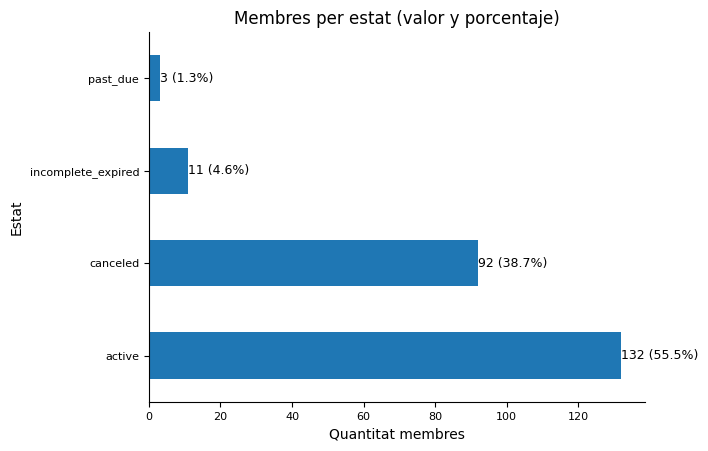

In [20]:
EvolucioMembresiMembresActius['alta_x'] = pd.to_datetime(EvolucioMembresiMembresActius['alta_x'], errors='coerce')
EvolucioMembresiMembresActius = EvolucioMembresiMembresActius.sort_values('alta_x', ascending=False)
entradas_recientes = EvolucioMembresiMembresActius.drop_duplicates(subset='membre', keep='first')
conteo = entradas_recientes.groupby('status_x')['membre'].nunique()
total = conteo.sum()
ax = conteo.plot.barh()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=8)
for p in ax.patches:
    valor = p.get_width()
    porcentaje = valor / total * 100
    etiqueta = f'{int(valor)} ({porcentaje:.1f}%)'
    ax.annotate(
        etiqueta,
        (valor, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9
    )
plt.xlabel('Quantitat membres')
plt.ylabel('Estat')
plt.title('Membres per estat (valor y porcentaje)')
plt.show()

In [21]:
entradas_recientes

,membre,status_x,alta_x,ultim_pagament,quota,email,codipostal,poblacio,status_y,antiguitat,alta_y,baixa
72,diana mizrahi cengarle,incomplete_expired,2025-07-05,2025-08-05,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,carla d'arnaude,active,2025-07-04,2025-08-04,10.0,carladdc@yahoo.com,8024,barcelona,active,Menys d'un mes,2025-04-07,NaT
6,alba soler abril,active,2025-07-04,2025-08-04,10.0,alba.soler.abril@gmail.com,8301,mataro,active,Menys d'un mes,2025-04-07,NaT
233,roberta causa,active,2025-07-04,2025-08-04,10.0,causa.roberta@gmail.com,8012,barcelona,active,Menys d'un mes,2025-04-07,NaT
137,laia haiyang sala rodo,active,2025-07-03,2025-08-03,10.0,laiasala2000@gmail.com,8023,barcelona,active,Menys d'un mes,2025-03-07,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
135,laia gual,active,2024-09-16,2025-07-16,10.0,laia.gual.clua@gmail.com,8011,barcelona,active,10 mesos,2024-09-16,NaT
156,malena cousinet,active,2024-09-16,2025-07-16,10.0,malenacousinet@gmail.com,8004,barcelona,active,10 mesos,2024-09-16,NaT
29,anna casas tortosa,active,2024-09-12,2025-07-12,10.0,valecasajanna@gmail.com,8192,sant quirze del valles,active,10 mesos,2024-12-09,NaT
193,miljana lakicevic,NaN,NaT,NaN,NaN,lakicevicmilj@gmail.com,46021,valencia,active,1 month,2025-05-28,NaT


In [22]:
nombresactivos = entradas_recientes[entradas_recientes['status_x'] == 'active']['membre'].unique()
unitats_total = CreditMembres[CreditMembres['membre'].isin(nombresactivos)]['unitats'].sum()
unitats_total

np.int64(2935)

In [23]:
nombresnoactivos = entradas_recientes[entradas_recientes['status_x'] != 'active']['membre'].unique()
unitats_total_canceled = CreditMembres[CreditMembres['membre'].isin(nombresnoactivos)]['unitats'].sum()
unitats_total_canceled

np.int64(1026)

In [24]:
CreditMembres

,membre,categoria,peca,unitats
0,a fernandez,tops,jersei,1
1,a fernandez,bottoms,pantalons llargs,1
2,adria linares i prenafeta,tops,polo,1
3,adria linares i prenafeta,tops,samarreta,7
4,adria linares i prenafeta,tops,jersei,2
...,...,...,...,...
1511,youssef charkaoui koubaa,bottoms,pantalons llargs,2
1512,youssef charkaoui koubaa,tops,camisa de maniga curta,1
1513,youssef charkaoui koubaa,tops,camisa,1
1514,youssef charkaoui koubaa,tops,jaqueta,1


In [25]:
CreditMembres['unitats'].sum()

np.int64(3966)

In [26]:
VisitesiCanvis['qtd_canvis'].sum()

np.float64(909.0)

In [27]:
canvis_total

NameError: name 'canvis_total' is not defined

In [148]:
usuarios_activos = EvolucioMembresiMembresActius[EvolucioMembresiMembresActius['status'] == 'active']
usuarios_activos= usuarios_activos.drop(columns=['alta_y', 'baixa'])
usuarios_activos = usuarios_activos.rename(columns={
    "alta_x":"alta"
})

usuarios_activos[usuarios_activos['quota'].isna()]

,membre,status,alta,ultim_pagament,quota,email,codipostal,poblacio,antiguitat
88,francesca frigeri,active,NaN,NaN,NaN,francesca.frigeri@gmail.com,8004,barcelona,2 mesos
195,miljana lakicevic,active,NaN,NaN,NaN,lakicevicmilj@gmail.com,46021,valencia,1 month
252,sonia pia podesta gonzalez,active,NaN,NaN,NaN,podestapia@gmail.com,8037,barcelona,Menys d'un mes


In [149]:
EvolucioMembres[EvolucioMembres['membre']=='francesca frigeri']

,membre,status,alta,ultim_pagament,quota
88,francesca frigeri,canceled,2024-09-25,2025-05-25,10.0
89,francesca frigeri,past_due,2025-05-06,2025-08-06,10.0
